In [44]:
import seaborn as sns
import matplotlib.pyplot  as plt
import pandas as pd 

In [45]:
!pip install seaborn



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
df = pd.read_csv('../data/cleaned_titanicdata.csv')

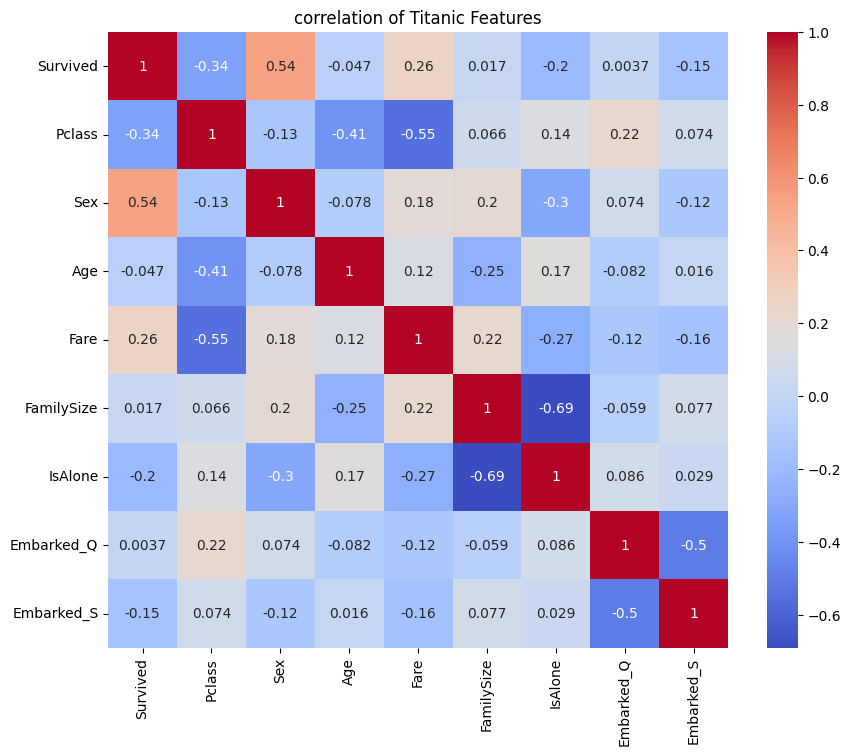

In [47]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),cmap='coolwarm',annot=True)
plt.title("correlation of Titanic Features")
plt.show()

### Survival Rate by Gender

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1292\737336186.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['Sex'].map({0:'Male',1:'Female'}),y='Survived',data=df,palette= 'magma')


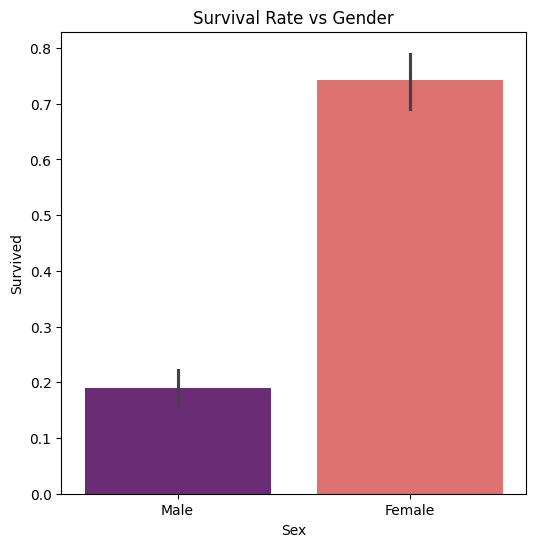

In [48]:
plt.figure(figsize=(6,6))
sns.barplot(x=df['Sex'].map({0:'Male',1:'Female'}),y='Survived',data=df,palette= 'magma')
plt.title("Survival Rate vs Gender")
plt.show()

### Survival Rate by Family Size

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1292\834871725.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FamilySize',y='Survived',data=df,palette='viridis')


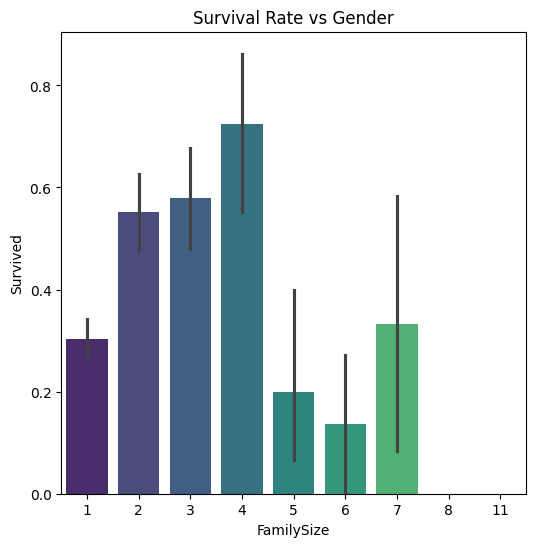

In [49]:
plt.figure(figsize=(6,6))
sns.barplot(x='FamilySize',y='Survived',data=df,palette='viridis')
plt.title("Survival Rate vs Gender")
plt.show()

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold,cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier 

#split data into Features andf target 
x = df.drop(columns=['Survived'])
y = df['Survived']

# create training and testing sets
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)

numeric_cols = x.select_dtypes(include=['int64','float64']).columns
preprocess = ColumnTransformer(
    transformers=[("num", StandardScaler(), numeric_cols)],
    remainder = "passthrough"
)

#create a dictionary of models 
models = {
    'Logistic Regression' : Pipeline([
        ("prep",preprocess),
        ('model',LogisticRegression(max_iter=1000))
    ]),
    'Random Forest': Pipeline([
        ("prep",preprocess),
          ('model',RandomForestClassifier(
        n_estimators=100,random_state=42,max_depth=4,
        min_samples_split=8,min_samples_leaf=2))]),
    #min_samples_split =minimum number of samples required in a node before the tree is allowed to split it further
    #min_samples_leaf → controls minimum samples in final leaf node
    'XGBoost':  Pipeline([
        ("prep",preprocess),
        ('model',XGBClassifier(
        n_estimators =200,learning_rate=0.03,max_depth =3,
        subsample=0.7,colsample_bytree=0.7,
        reg_alpha=1,
        reg_lambda=1,
        eval_metric = 'logloss',random_state=42
    ))
        ]),
    'SVM': Pipeline([
        ("prep",preprocess),
        ("model",SVC())
    ])

}

#loop through and test each one 
for name, model in models.items():

    model.fit(x_train,y_train)

    train_pred = model.predict(x_train)
    train_acc = accuracy_score(y_train,train_pred)

    test_pred = model.predict(x_test)
    test_acc = accuracy_score(y_test,test_pred)
    
    print(f"{name}")
    print(f"  Train Accuracy: {train_acc*100:.2f}%")
    print(f"  Test  Accuracy: {test_acc*100:.2f}%\n")

    cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
    cv_scores = cross_val_score(model,x,y,cv=cv,scoring='accuracy')
    print(f"{name}:")
    print(f"Mean Accuracy:{cv_scores.mean()*100:.2f}%")
    print(f"Standard Deviation: {cv_scores.std()*100:.2f}%")
    # above this show how stable the model

    print("-"*30)



Logistic Regression
  Train Accuracy: 80.76%
  Test  Accuracy: 80.45%

Logistic Regression:
Mean Accuracy:80.36%
Standard Deviation: 2.05%
------------------------------
Random Forest
  Train Accuracy: 84.27%
  Test  Accuracy: 82.12%

Random Forest:
Mean Accuracy:82.49%
Standard Deviation: 1.35%
------------------------------
XGBoost
  Train Accuracy: 85.39%
  Test  Accuracy: 79.33%

XGBoost:
Mean Accuracy:83.16%
Standard Deviation: 2.27%
------------------------------
SVM
  Train Accuracy: 84.27%
  Test  Accuracy: 81.56%

SVM:
Mean Accuracy:82.71%
Standard Deviation: 1.59%
------------------------------


### Feature Importance

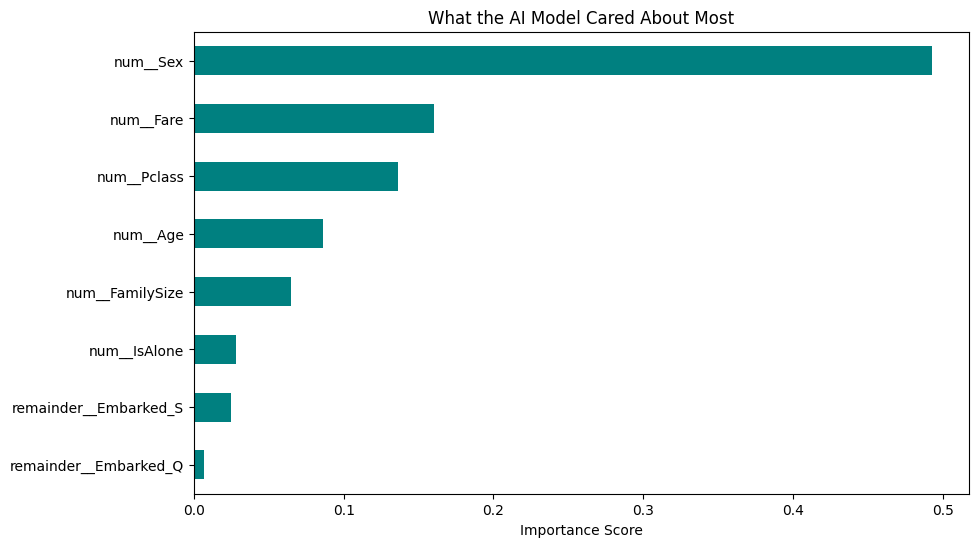

In [81]:
rf_pipline=models["Random Forest"]
rf_pipline.fit(x_train,y_train)

rf_model = rf_pipline.named_steps['model']
feature_names = rf_pipline.named_steps["prep"].get_feature_names_out()
importances = pd.Series(rf_model.feature_importances_,index=feature_names)
#model.feature_importances_→ gives an array of importance values from RandomForest
#index=x.columns→ assigns each importance score to its corresponding column name.
importances.sort_values().plot(kind='barh',color='teal',figsize=(10,6))
plt.title("What the AI Model Cared About Most")
plt.xlabel("Importance Score")
plt.show()

--Classification Report--
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       110
           1       0.84      0.67      0.74        69

    accuracy                           0.82       179
   macro avg       0.83      0.79      0.80       179
weighted avg       0.82      0.82      0.82       179



<function matplotlib.pyplot.show(close=None, block=None)>

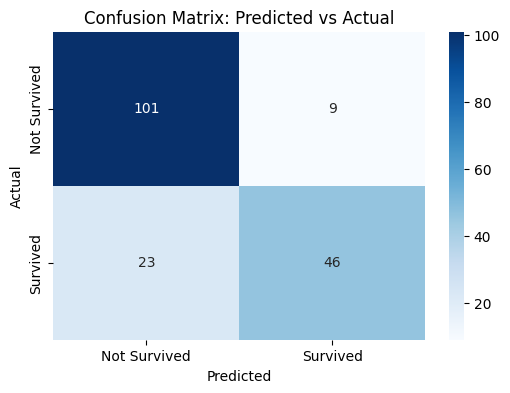

In [85]:
from sklearn.metrics import classification_report,confusion_matrix
#detailed report
prediction = rf_pipline.predict(x_test)
print("--Classification Report--")
print(classification_report(y_test,prediction))

#Comfusion Matrix
cm = confusion_matrix(y_test,prediction)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap="Blues",xticklabels=["Not Survived","Survived"],yticklabels=["Not Survived","Survived"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix: Predicted vs Actual")
plt.show

In [ ]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 989.2 kB/s eta 0:01:43
   ---------------------------------------- 0.8/101.7 MB 1.0 MB/s eta 0:01:40
   ---------------------------------------- 1.0/101.7 MB 1.2 MB/s eta 0:01:24
    --------------------------------------- 1.3/101.7 MB 1.3 MB/s eta 0:01:17
    --------------------------------------- 1.8/101.7 MB 1.4 MB/s eta 0:01:12
    --------------------------------------- 2.1/101.7 MB 1.4 MB/s eta 0:01:13
    --------------------------------------- 2.1/101.7 MB 1.4 MB/s eta 0:01:13
    --------------------------------------- 2.4/101.7 MB 1.3 MB/s eta 0:01:17
   - -------------------------------------- 2.6/101.7 MB 1.3 MB/s eta 0:01:18
   - --------


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
